# Modelo de Lead Scoring B2B

Este projeto tem como objetivo desenvolver um modelo preditivo de **Lead Scoring** B2B para ranquear e priorizar os leads com maior probabilidade de conversão.

### Técnicas Utilizadas
- **Feature Engineering:** Construção de novas variáveis voltadas ao contexto do negócio, como *engajamento por dia, lead quente, ticket normalizado por porte e indicador de venda complexa*.
- **Modelagem e Processamento:** Algoritmo `GradientBoostingClassifier` com padronização numérica e encoding categórico dentro de um `Pipeline`.
- **Calibração de Probabilidades:** Utilização de `CalibratedClassifierCV` (isotônico) para garantir alta confiabilidade nas probabilidades geradas, essencial para regras de negócio reais.
- **Explainable AI (XAI):** Aplicação de valores **SHAP** para interpretar o motivo das predições, abrindo a "caixa preta" do modelo e gerando confiança para a equipe comercial.

### Resultados Obtidos
- **Performance Geral:** O modelo demonstrou solidez com uma área sob a curva (ROC-AUC) de **~0.716** e Average Precision de **~0.803**.
- **Curva de Ganhos:** Comprovou a grande eficácia do rankeamento. O modelo demonstrou que focar os esforços de vendas apenas no **Top 30% dos leads** sugeridos é o suficiente para capturar a imensa maioria das conversões reais, poupando tempo valioso de prospecção.


- Organizando o Dataset

In [1]:
# Preparando as ferramentas necessárias para a análise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, RocCurveDisplay,
                             PrecisionRecallDisplay)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import shap
import warnings
warnings.filterwarnings('ignore')

# Seed para reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Dataset sintético com estrutura inspirada em funis B2B reais

def generate_b2b_leads(n=3000, seed=42):
    np.random.seed(seed)

    df = pd.DataFrame({
        # Perfil da empresa
        'company_size': np.random.choice(
            ['micro', 'pequena', 'media', 'grande'],
            n, p=[0.3, 0.35, 0.25, 0.1]
        ),
        'industry': np.random.choice(
            ['industria', 'servicos', 'varejo', 'tecnologia', 'agro'],
            n, p=[0.2, 0.25, 0.2, 0.25, 0.1]
        ),
        'anos_mercado': np.random.exponential(8, n).clip(1, 40).astype(int),

        # Comportamento no funil
        'num_contatos': np.random.poisson(4, n).clip(1, 20),
        'dias_no_funil': np.random.exponential(30, n).clip(1, 180).astype(int),
        'proposta_enviada': np.random.choice([0, 1], n, p=[0.4, 0.6]),
        'demo_realizada': np.random.choice([0, 1], n, p=[0.5, 0.5]),
        'num_decisores_envolvidos': np.random.choice([1,2,3,4], n, p=[0.4,0.35,0.2,0.05]),

        # Engajamento digital
        'emails_abertos': np.random.poisson(3, n).clip(0, 20),
        'visitas_site': np.random.poisson(5, n).clip(0, 50),
        'materiais_baixados': np.random.poisson(1, n).clip(0, 10),

        # Contexto comercial
        'origem_lead': np.random.choice(
            ['inbound', 'outbound', 'indicacao', 'evento'],
            n, p=[0.3, 0.4, 0.2, 0.1]
        ),
        'ticket_estimado': np.random.lognormal(10, 1, n).clip(5000, 500000),
        'regiao': np.random.choice(
            ['sul', 'sudeste', 'centro_oeste', 'nordeste', 'norte'],
            n, p=[0.2, 0.4, 0.15, 0.15, 0.1]
        ),
    })

    # Target com lógica realista (não aleatório puro)
    score = (
        (df['proposta_enviada'] * 1.5) +
        (df['demo_realizada'] * 1.2) +
        (df['num_contatos'] * 0.1) +
        (df['emails_abertos'] * 0.08) +
        (df['materiais_baixados'] * 0.2) +
        (df['num_decisores_envolvidos'] * 0.3) +
        (df['origin_bonus'] if 'origin_bonus' in df.columns else
         df['origem_lead'].map({'indicacao': 0.8, 'inbound': 0.4,
                                 'evento': 0.3, 'outbound': 0.0})) +
        np.random.normal(0, 0.5, n)
    )

    prob = 1 / (1 + np.exp(-score + 2.5))
    df['converteu'] = (np.random.uniform(0,1,n) < prob).astype(int)

    return df

df = generate_b2b_leads(3000)
print(f"Shape: {df.shape}")
print(f"Taxa de conversão: {df['converteu'].mean():.1%}")
df.head()

Shape: (3000, 15)
Taxa de conversão: 63.3%


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,company_size,industry,anos_mercado,num_contatos,dias_no_funil,proposta_enviada,demo_realizada,num_decisores_envolvidos,emails_abertos,visitas_site,materiais_baixados,origem_lead,ticket_estimado,regiao,converteu
0,pequena,tecnologia,8,6,21,1,1,2,4,4,2,outbound,118526.522945,sudeste,0
1,grande,tecnologia,1,4,14,0,0,2,5,1,0,inbound,14654.624132,nordeste,0
2,media,servicos,16,1,18,1,0,1,8,3,1,outbound,16035.299312,centro_oeste,1
3,pequena,varejo,7,2,30,1,0,3,4,2,0,inbound,22533.233098,centro_oeste,1
4,micro,varejo,1,3,81,1,0,1,2,4,3,evento,14772.799846,nordeste,1


- Análise Exploratória

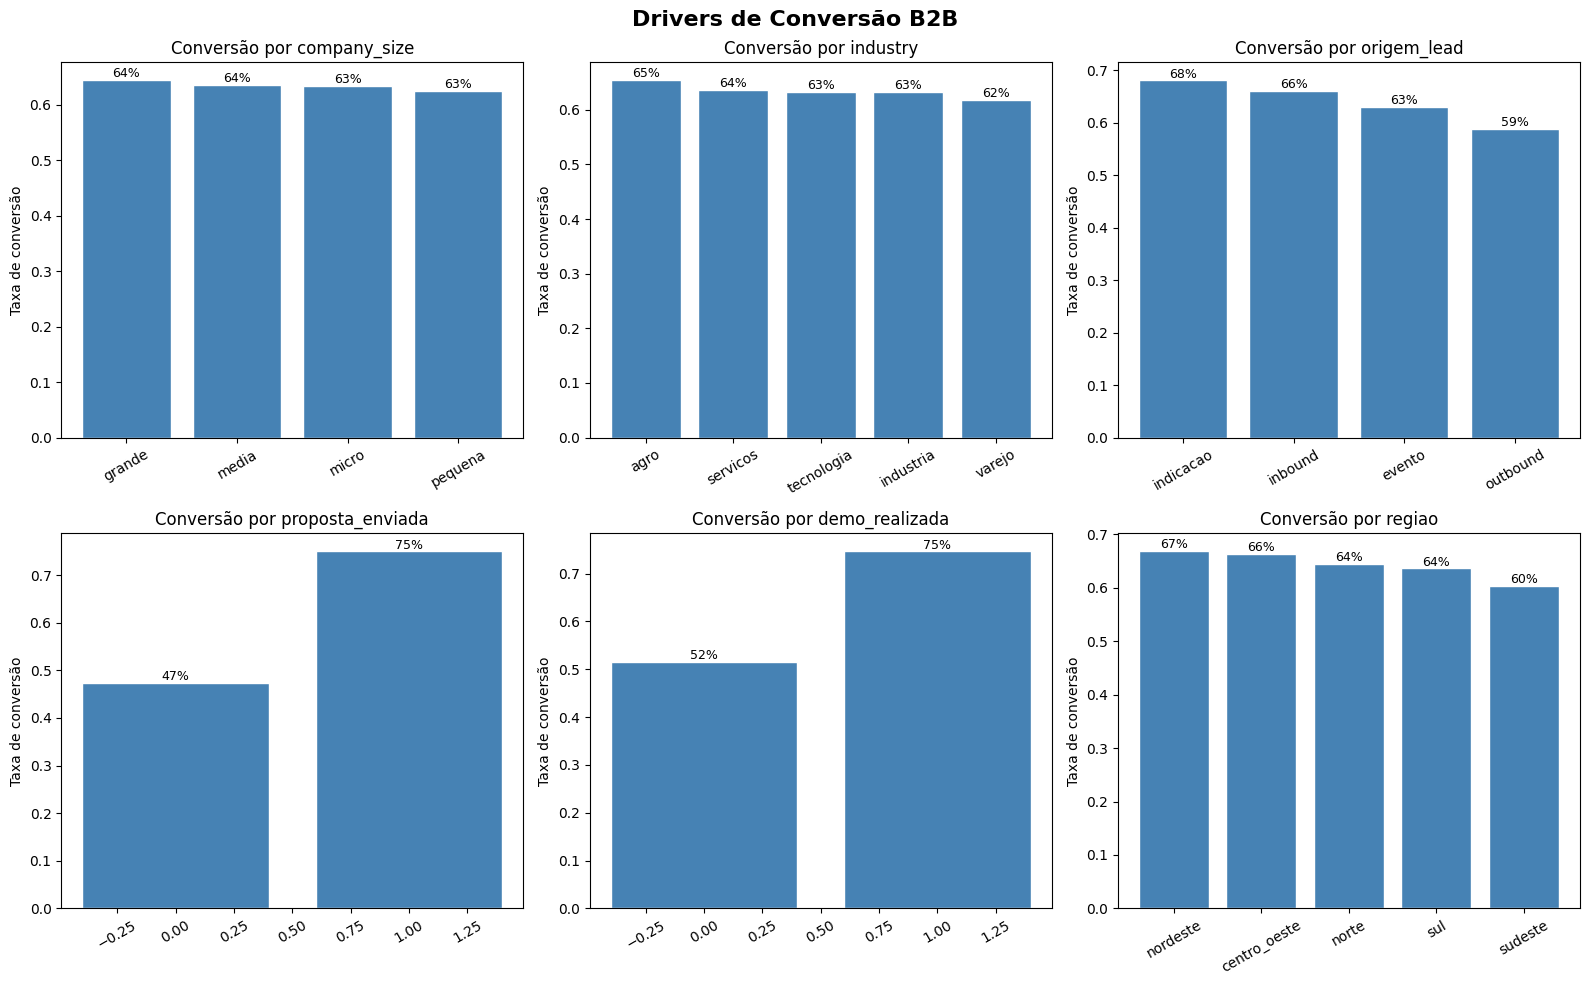

In [2]:
# Conversão por variáveis-chave — visão de negócio primeiro
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Drivers de Conversão B2B', fontsize=16, fontweight='bold')

cats = ['company_size', 'industry', 'origem_lead',
        'proposta_enviada', 'demo_realizada', 'regiao']

for ax, col in zip(axes.flatten(), cats):
    conv = df.groupby(col)['converteu'].mean().sort_values(ascending=False)
    bars = ax.bar(conv.index, conv.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Conversão por {col}')
    ax.set_ylabel('Taxa de conversão')
    ax.tick_params(axis='x', rotation=30)
    # Adiciona % em cada barra
    for bar, val in zip(bars, conv.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.0%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

- Feature Engineering — encontrando o alpha

In [3]:
def feature_engineering(df):
    df = df.copy()

    # Velocidade de engajamento (quanto engajamento por dia no funil)
    df['engajamento_por_dia'] = (
        df['emails_abertos'] + df['visitas_site'] * 2 + df['materiais_baixados'] * 3
    ) / df['dias_no_funil'].clip(1)

    # Lead quente: proposta + demo = sinal forte
    df['lead_quente'] = (df['proposta_enviada'] & df['demo_realizada']).astype(int)

    # Ticket normalizado por porte
    size_map = {'micro': 1, 'pequena': 2, 'media': 3, 'grande': 4}
    df['porte_num'] = df['company_size'].map(size_map)
    df['ticket_por_porte'] = df['ticket_estimado'] / df['porte_num']

    # Complexidade da venda (mais decisores = mais difícil, mas quando fecha é certo)
    df['venda_complexa'] = (df['num_decisores_envolvidos'] >= 3).astype(int)

    # Log do ticket (distribuição menos assimétrica)
    df['log_ticket'] = np.log1p(df['ticket_estimado'])

    return df

df = feature_engineering(df)
print("Features criadas:", ['engajamento_por_dia', 'lead_quente',
                             'ticket_por_porte', 'venda_complexa', 'log_ticket'])

Features criadas: ['engajamento_por_dia', 'lead_quente', 'ticket_por_porte', 'venda_complexa', 'log_ticket']


- Modelagem dos dados

In [4]:
# Definição de features
NUM_FEATURES = [
    'anos_mercado', 'num_contatos', 'dias_no_funil',
    'num_decisores_envolvidos', 'emails_abertos', 'visitas_site',
    'materiais_baixados', 'log_ticket', 'engajamento_por_dia',
    'ticket_por_porte'
]

CAT_FEATURES = ['company_size', 'industry', 'origem_lead', 'regiao']

BIN_FEATURES = ['proposta_enviada', 'demo_realizada', 'lead_quente', 'venda_complexa']

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES + BIN_FEATURES
TARGET = 'converteu'

X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Treino: {X_train.shape} | Conversão: {y_train.mean():.1%}")
print(f"Teste:  {X_test.shape}  | Conversão: {y_test.mean():.1%}")

# Pipeline com preprocessamento
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
    ('bin', 'passthrough', BIN_FEATURES)
])

# Modelo principal: GBM calibrado (probabilidades confiáveis são críticas aqui)
gbm = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=SEED
)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', CalibratedClassifierCV(gbm, cv=5, method='isotonic'))
])

pipeline.fit(X_train, y_train)
print("Modelo treinado.")

Treino: (2400, 18) | Conversão: 63.2%
Teste:  (600, 18)  | Conversão: 63.3%
Modelo treinado.


- Realizando avaliação de métricas relevantes para o negócio

  ROC-AUC:          0.7160
  Avg Precision:    0.8035


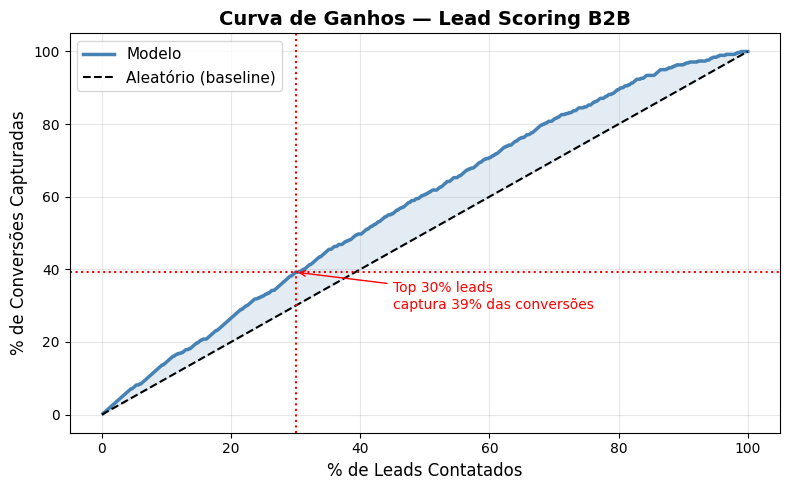

In [5]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("=" * 45)
print(f"  ROC-AUC:          {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Avg Precision:    {average_precision_score(y_test, y_prob):.4f}")
print("=" * 45)

# Utilizando ROC-AUC, uma boa prática em Lead Scoring para rankear com qualidade os leads bons e ruins

# Curva de Ganhos — linguagem do comercial
def plot_gains_curve(y_true, y_score):
    order = np.argsort(y_score)[::-1]
    y_sorted = np.array(y_true)[order]

    total_pos = y_sorted.sum()
    gains = np.cumsum(y_sorted) / total_pos
    pct_leads = np.arange(1, len(y_sorted)+1) / len(y_sorted)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(pct_leads * 100, gains * 100, color='steelblue', lw=2.5,
            label='Modelo')
    ax.plot([0, 100], [0, 100], 'k--', lw=1.5, label='Aleatório (baseline)')
    ax.fill_between(pct_leads * 100, gains * 100,
                    pct_leads * 100, alpha=0.15, color='steelblue')

    # Linha de referência: top 30% dos leads
    idx_30 = int(0.3 * len(gains))
    ax.axvline(30, color='red', ls=':', lw=1.5)
    ax.axhline(gains[idx_30] * 100, color='red', ls=':', lw=1.5)
    ax.annotate(f'Top 30% leads\ncaptura {gains[idx_30]:.0%} das conversões',
                xy=(30, gains[idx_30]*100), xytext=(45, gains[idx_30]*100 - 10),
                fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

    ax.set_xlabel('% de Leads Contatados', fontsize=12)
    ax.set_ylabel('% de Conversões Capturadas', fontsize=12)
    ax.set_title('Curva de Ganhos — Lead Scoring B2B', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_gains_curve(y_test, y_prob)

- Interpretação dos resultados

PermutationExplainer explainer: 201it [01:41,  1.89it/s]                         


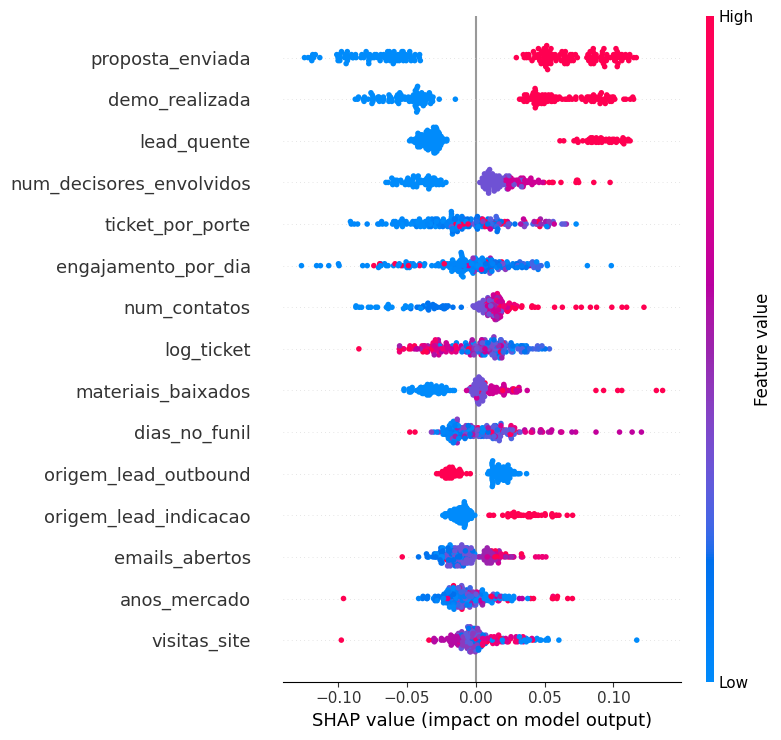

In [6]:
# SHAP explica cada predição — essencial para o comercial confiar no modelo

# 1. Criar uma função "callable" que retorna apenas a probabilidade da classe 1 (converteu)
predict_fn = lambda x: pipeline.named_steps['model'].predict_proba(x)[:, 1]

# 2. Pegar um sample do X_train transformado para servir de base (masker)
X_train_transformed = pipeline.named_steps['prep'].transform(X_train)
background = shap.sample(X_train_transformed, 100) # 100 amostras é o suficiente e muito mais rápido

# 3. Iniciar o Explainer passando a função e o background
explainer = shap.Explainer(predict_fn, background)

# 4. Transformar os dados de teste e calcular os valores SHAP
X_test_transformed = pipeline.named_steps['prep'].transform(X_test)
shap_values = explainer(X_test_transformed[:200])

# Feature names pós-encoding
cat_names = pipeline.named_steps['prep']\
    .named_transformers_['cat'].get_feature_names_out(CAT_FEATURES).tolist()
feature_names = NUM_FEATURES + cat_names + BIN_FEATURES

# Plotando
shap.summary_plot(shap_values, X_test_transformed[:200],
                  feature_names=feature_names, max_display=15)


- Resumo para o comercial

In [7]:
# Geração do score final para o CRM
def gerar_score_comercial(df_leads, pipeline):
    scores = pipeline.predict_proba(df_leads[ALL_FEATURES])[:, 1]

    resultado = df_leads.copy()
    resultado['prob_conversao'] = scores

    # Segmentação em tiers — linguagem de negócio
    resultado['tier'] = pd.cut(
        scores,
        bins=[0, 0.3, 0.6, 0.8, 1.0],
        labels=['Frio', 'Morno', 'Quente', 'Crítico']
    )

    # Prioridade de ação
    resultado['acao_recomendada'] = resultado['tier'].map({
        'Crítico':  'Ligar HOJE — alto potencial de conversão',
        'Quente':   'Agendar reunião esta semana',
        'Morno':   'Nutrir com conteúdo + follow-up em 15d',
        'Frio':    'Manter em automação de marketing'
    })

    return resultado.sort_values('prob_conversao', ascending=False)

df_scored = gerar_score_comercial(X_test, pipeline)
print(df_scored[['prob_conversao', 'tier', 'acao_recomendada']].head(10))
print("\nDistribuição por tier:")
print(df_scored['tier'].value_counts())

      prob_conversao     tier                          acao_recomendada
2095        0.955333  Crítico  Ligar HOJE — alto potencial de conversão
1161        0.955333  Crítico  Ligar HOJE — alto potencial de conversão
245         0.953521  Crítico  Ligar HOJE — alto potencial de conversão
1965        0.938667  Crítico  Ligar HOJE — alto potencial de conversão
2585        0.930333  Crítico  Ligar HOJE — alto potencial de conversão
1980        0.929628  Crítico  Ligar HOJE — alto potencial de conversão
17          0.918667  Crítico  Ligar HOJE — alto potencial de conversão
397         0.918667  Crítico  Ligar HOJE — alto potencial de conversão
962         0.916300  Crítico  Ligar HOJE — alto potencial de conversão
2260        0.913667  Crítico  Ligar HOJE — alto potencial de conversão

Distribuição por tier:
tier
Quente     269
Morno      201
Crítico    109
Frio        21
Name: count, dtype: int64
